In [ ]:
!pip install micropip

In [ ]:
#MODEL DEVELOPMENT
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
file_path= "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv"
df=pd.read_csv(file_path)

In [ ]:
from sklearn.linear_model import LinearRegression
lm=LinearRegression() #Creating object


In [ ]:
x=df[['highway-mpg']]
y=df['price']
lm.fit(x,y)
yhat=lm.predict(x)
yhat[0:5]

array([16236.50464347, 16236.50464347, 17058.23802179, 13771.3045085 ,
       20345.17153508])

In [ ]:
print(lm.intercept_)
print(lm.coef_)

38423.3058581574
[-821.73337832]


In [ ]:
#Multiple linear regression
Z = df[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']]
lm.fit(Z,df['price'])

LinearRegression()

In [ ]:
lm.intercept_

np.float64(-15806.62462632922)

In [ ]:
lm.coef_

array([53.49574423,  4.70770099, 81.53026382, 36.05748882])

(0.0, 48167.02874977586)

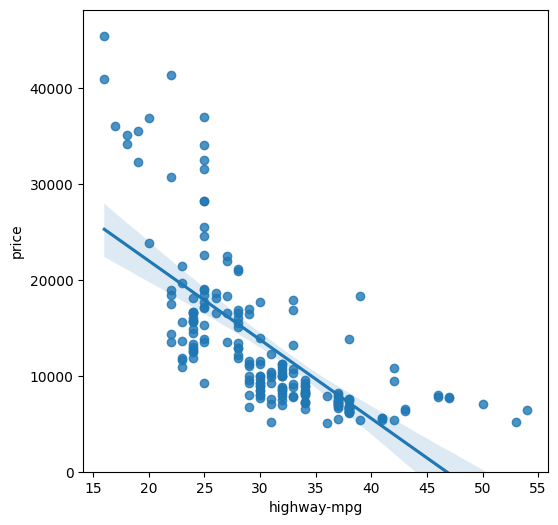

In [ ]:
#MODEL EVALUATION
plt.figure(figsize=(6,6))
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)

(0.0, 47414.1)

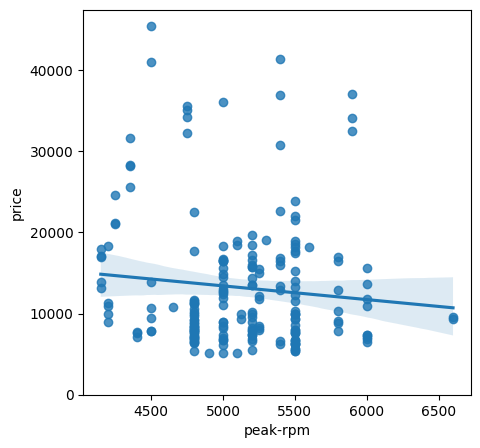

In [ ]:
plt.figure(figsize=(5,5))
sns.regplot(x="peak-rpm", y="price", data=df)
plt.ylim(0,)

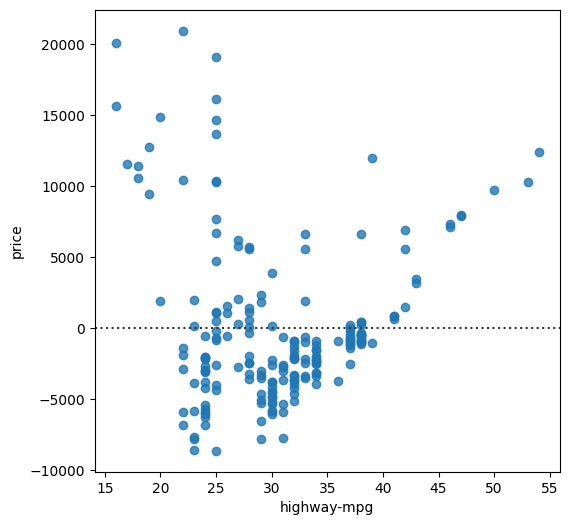

In [ ]:
#RESIDUAL PLOT

plt.figure(figsize=(6,6))
sns.residplot(x=df[['highway-mpg']],y=df['price'])
plt.show()

__Observation__: There's a discernible pattern (a curve, or a funnel shape indicating changing variance), it would imply that the linear model might not be the best fit for the data, or that the variance of the errors is not constant (heteroscedasticity).

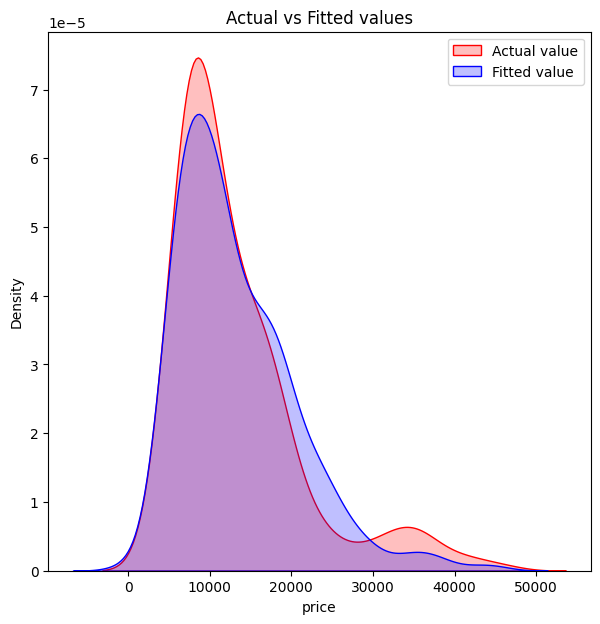

In [ ]:
#Distribution plot
Y_hat=lm.predict(Z)
plt.figure(figsize=(7,7))
ax = sns.kdeplot(df['price'], color='r', label='Actual value', fill=True)
sns.kdeplot(Y_hat, color='b', label='Fitted value', fill=True, ax=ax)
plt.title('Actual vs Fitted values')
plt.xlabel('price')
plt.ylabel('Density')
plt.legend()
plt.show()

__Observation__:A significant overlap indicates that the model's predictions are distributed similarly to the real data, capturing the overall shape and spread of the prices reasonably well. The tighter the overlap, the better the model's fit to the data's distribution.

        3         2
-1.557 x + 204.8 x - 8965 x + 1.379e+05


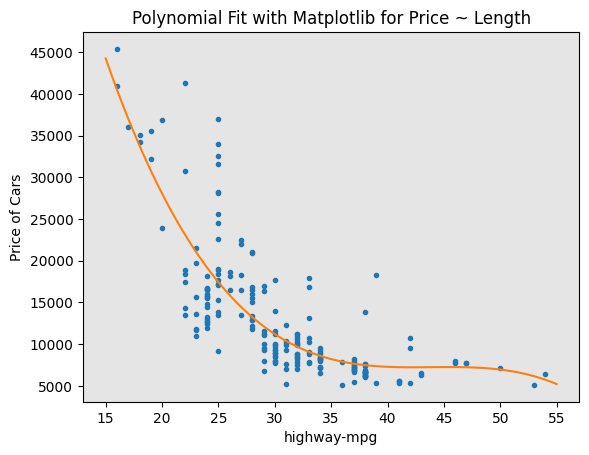

In [ ]:
#Polyfitting..

def Polyfitting(model,independent_var,dependent_var,Name):
  x_=np.linspace(15,55,100)
  y_=model(x_)
  plt.plot(independent_var, dependent_var, '.', x_, y_, '-')
  plt.title('Polynomial Fit with Matplotlib for Price ~ Length')
  ax=plt.gca()
  ax.set_facecolor((0.898, 0.898, 0.898))
  fig = plt.gcf()
  plt.xlabel(Name)
  plt.ylabel('Price of Cars')
  plt.show()

x = df['highway-mpg']
y = df['price']

#Fitting the polynomial

f = np.polyfit(x, y, 3)
p = np.poly1d(f)
print(p)

Polyfitting(p, x, y, 'highway-mpg')

__Observation__: Looking at the plots, the regplot for 'highway-mpg' vs 'price' (cell 4gQmcAKoMUqJ) might show that a straight line doesn't perfectly capture the trend. There might be a noticeable curve in the data points that the linear model struggles to fit. In contrast, the Polyfitting plot, which uses a polynomial function (in this case, a cubic polynomial as indicated by np.polyfit(x, y, 3)), will likely show the fitted curve following the data points more closely. Also, the cubic equation for the relation is as follos:               
     -1.557 x^3+ 204.8 x^2 - 8965 x + 1.379e+05

/tmp/ipykernel_2021/1143829715.py:1: RankWarning: Polyfit may be poorly conditioned
  f=np.polyfit(x,y,20)


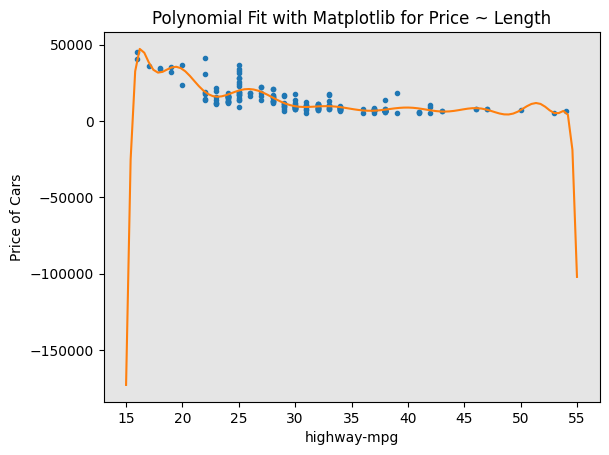

In [ ]:
f=np.polyfit(x,y,20)
p=np.poly1d(f)
Polyfitting(p,x,y,'highway-mpg')

### Model Evaluation: Polynomial Regression

We will now evaluate the performance of the polynomial models using metrics like R-squared and Mean Squared Error (MSE).

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

# --- Re-fitting and evaluating degree 3 polynomial model ---
# Ensure we have the correct polynomial for degree 3
f_3 = np.polyfit(x, y, 3)
p_3 = np.poly1d(f_3)
y_pred_poly3 = p_3(x)

r2_poly3 = r2_score(y, y_pred_poly3)
mse_poly3 = mean_squared_error(y, y_pred_poly3)

print(f"Degree 3 Polynomial Model:\n  R-squared: {r2_poly3:.4f}\n  MSE: {mse_poly3:.2f}\n")

# --- Evaluating degree 20 polynomial model ---
# Ensure we have the correct polynomial for degree 20
# (f_20 and p_20 were already created in the previous cell or in the original run of this cell)
f_20 = np.polyfit(x, y, 20)
p_20 = np.poly1d(f_20)
y_pred_poly20 = p_20(x)

r2_poly20 = r2_score(y, y_pred_poly20)
mse_poly20 = mean_squared_error(y, y_pred_poly20)

print(f"Degree 20 Polynomial Model:\n  R-squared: {r2_poly20:.4f}\n  MSE: {mse_poly20:.2f}")

Degree 3 Polynomial Model:
  R-squared: 0.6742
  MSE: 20474146.43

Degree 20 Polynomial Model:
  R-squared: 0.7487
  MSE: 15789195.95


/tmp/ipykernel_2021/1386288127.py:17: RankWarning: Polyfit may be poorly conditioned
  f_20 = np.polyfit(x, y, 20)


In [ ]:
#_______________________________________________________________________________
#                 PIPELINE
#_______________________________________________________________________________
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

Input=[('scale',StandardScaler()),('polynomial',PolynomialFeatures(include_bias=False)),('model',LinearRegression())]
pipe=Pipeline(Input)
Z=Z.astype(float)
pipe.fit(Z,y)
ypipe=pipe.predict(Z)
ypipe[0:4]

array([13102.74784201, 13102.74784201, 18225.54572197, 10390.29636555])

In [ ]:
#highway_mpg_fit
lm.fit(df[['highway-mpg']], df['price'])
# Find the R^2
print('The R-square is: ', lm.score(df[['highway-mpg']], df['price']))

The R-square is:  0.4965911884339176


In [ ]:
Yhat=lm.predict(df[['highway-mpg']])
print('The output of the first four predicted value is: ', Yhat[0:4])

The output of the first four predicted value is:  [16236.50464347 16236.50464347 17058.23802179 13771.3045085 ]


In [ ]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(df['price'], Yhat)
print('The mean square error of price and predicted value is: ', mse)

The mean square error of price and predicted value is:  31635042.944639888


In [ ]:
#_______________________________________________________________________________
#            MULTIPLE LINEAR REGRESSION
#_______________________________________________________________________________

# fit the model
lm.fit(Z, df['price'])
# Find the R^2
print('The R-square is: ', lm.score(Z, df['price']))

Y_predict_multifit = lm.predict(Z)
print('The mean square error of price and predicted value using multifit is: ', \
      mean_squared_error(df['price'], Y_predict_multifit))

The R-square is:  0.8093562806577457
The mean square error of price and predicted value using multifit is:  11980366.87072649


In [ ]:
#_______________________________________________________________________________
#            POLYNOMIAL FIT
#_______________________________________________________________________________
r_squared = r2_score(y, p(x))
print('The R-square value is: ', r_squared)

print("The mean squared error of polynomial fit model:",mean_squared_error(df['price'], p(x)))

The R-square value is:  0.7487463386315785
The mean squared error of polynomial fit model: 15789195.947247809


# PREDICTION AND DECISION MAKING

## Simple Linear Regression: Using Highway-mpg as a Predictor Variable of Price.
R-squared: 0.49659118843391759

MSE: 3.16 x10^7

## Multiple Linear Regression: Using Horsepower, Curb-weight, Engine-size, and Highway-mpg as Predictor Variables of Price.
R-squared: 0.80896354913783497

MSE: 1.2 x10^7

## Polynomial Fit: Using Highway-mpg as a Predictor Variable of Price.
R-squared: 0.6741946663906514

MSE: 2.05 x 10^7


__Thereby multiple linear regression is the best fit for model training with smallest MSE and largest R-squared__


In [ ]:
#-------------------------------------------------------------------------------
#                         MODEL EVALUATION AND REFINEMENT..
#_______________________________________________________________________________

import scipy

ed=df._get_numeric_data()
ed


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
0,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,11.190476,0,1
1,3,122,88.6,0.811148,0.890278,48.8,2548,130,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,11.190476,0,1
2,1,122,94.5,0.822681,0.909722,52.4,2823,152,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,12.368421,0,1
3,2,164,99.8,0.848630,0.919444,54.3,2337,109,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,9.791667,0,1
4,2,164,99.4,0.848630,0.922222,54.3,2824,136,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,13.055556,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-1,95,109.1,0.907256,0.956944,55.5,2952,141,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0,10.217391,0,1
197,-1,95,109.1,0.907256,0.955556,55.5,3049,141,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0,12.368421,0,1
198,-1,95,109.1,0.907256,0.956944,55.5,3012,173,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0,13.055556,0,1
199,-1,95,109.1,0.907256,0.956944,55.5,3217,145,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0,9.038462,1,0


In [ ]:
#         VISUALISATION
def DistributionPlot(RedFunction, BlueFunction, RedName, BlueName, Title):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))

    ax1 = sns.kdeplot(RedFunction, color="r", label=RedName)
    ax2 = sns.kdeplot(BlueFunction, color="b", label=BlueName, ax=ax1)

    plt.title(Title)
    plt.xlabel('Price (in dollars)')
    plt.ylabel('Proportion of Cars')
    plt.show()
    plt.close()


def PollyPlot(xtrain, xtest, y_train, y_test, lr,poly_transform):
    width = 12
    height = 10
    plt.figure(figsize=(width, height))

    #training data and testing data
    #poly_transform:  polynomial transformation object

    xmax=max([xtrain.values.max(), xtest.values.max()])

    xmin=min([xtrain.values.min(), xtest.values.min()])

    x=np.arange(xmin, xmax, 0.1)


    plt.plot(xtrain, y_train, 'ro', label='Training Data')
    plt.plot(xtest, y_test, 'go', label='Test Data')
    plt.plot(x, lr.predict(poly_transform.fit_transform(x.reshape(-1, 1))), label='Predicted Function')
    plt.ylim([-10000, 60000])
    plt.ylabel('Price')
    plt.legend()

y_data=df['price']
x_data=df.drop('price',axis=1)
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.20, random_state=1)
#setting 80% of the data for training and 20% for testing.....
print("number of test samples :", x_test.shape[0])
print("number of training samples:",x_train.shape[0])
lre=LinearRegression() #Creating another Linear Regression model object.
lre.fit(x_train[['horsepower']],y_train) #Fitting the model
print("R-sqaured for train data is:",lre.score(x_train[['horsepower']],y_train))
print("R-sqaured for test data is:",lre.score(x_test[['horsepower']],y_test))

number of test samples : 41
number of training samples: 160
R-sqaured for train data is: 0.6719873936874949
R-sqaured for test data is: 0.5699549409405678


In [ ]:
#R-squared for the training data (0.6719) is higher than the R-squared for the test data (0.5699),is a strong indication of overfitting.
#CROSS VALIDATION SCORE.............
from sklearn.model_selection import cross_val_score
Rcross=cross_val_score(lre,x_data[['horsepower']],y_data,cv=4)
print("Rcross:",Rcross)
print("The mean of the folds are:",Rcross.mean())
print("The standard deviation of the folds are :",Rcross.std())
print("Negative MSE:",-1 * cross_val_score(lre,x_data[['horsepower']], y_data,cv=4,scoring='neg_mean_squared_error'))


Rcross: [0.7746232  0.51716687 0.74785353 0.04839605]
The mean of the folds are: 0.522009915042119
The standard deviation of the folds are : 0.291183944475603
Negative MSE: [20254142.84026702 43745493.2650517  12539630.34014931 17561927.72247591]


In [ ]:
#predicting the output using cross_val_predict
from sklearn.model_selection import cross_val_predict
yhat=cross_val_predict(lre,x_data[['horsepower']],y_data,cv=4)
yhat[0:5]

array([14141.63807508, 14141.63807508, 20814.29423473, 12745.03562306,
       14762.35027598])

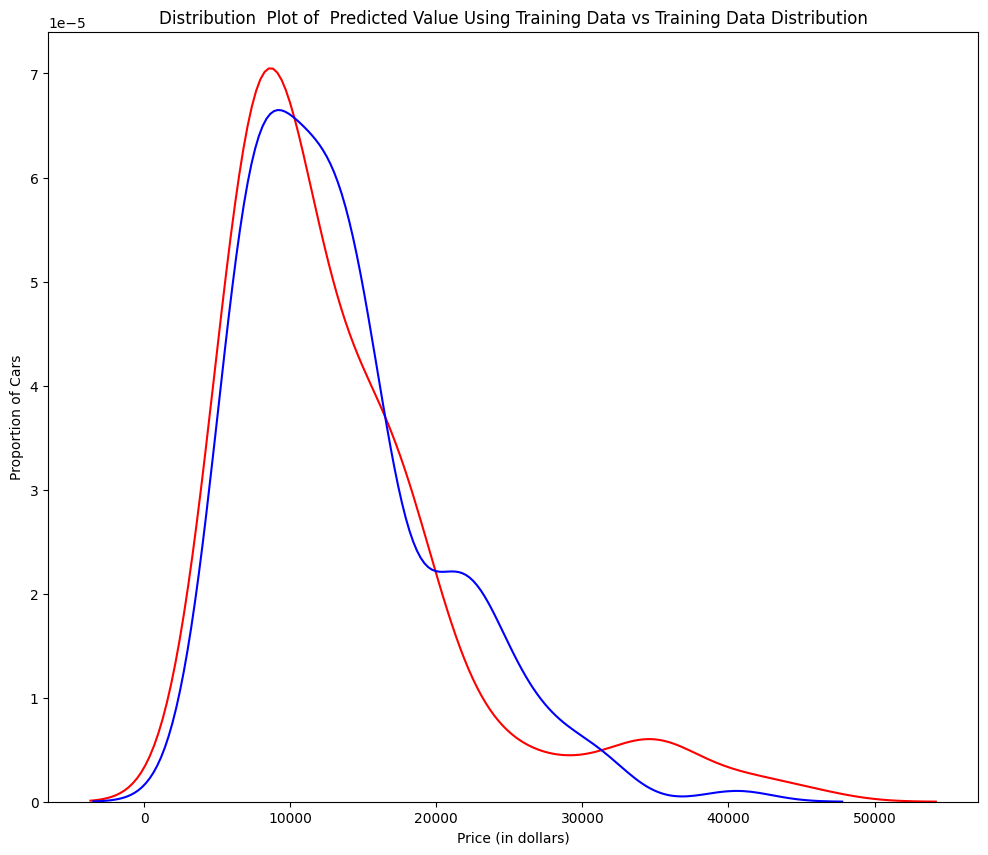

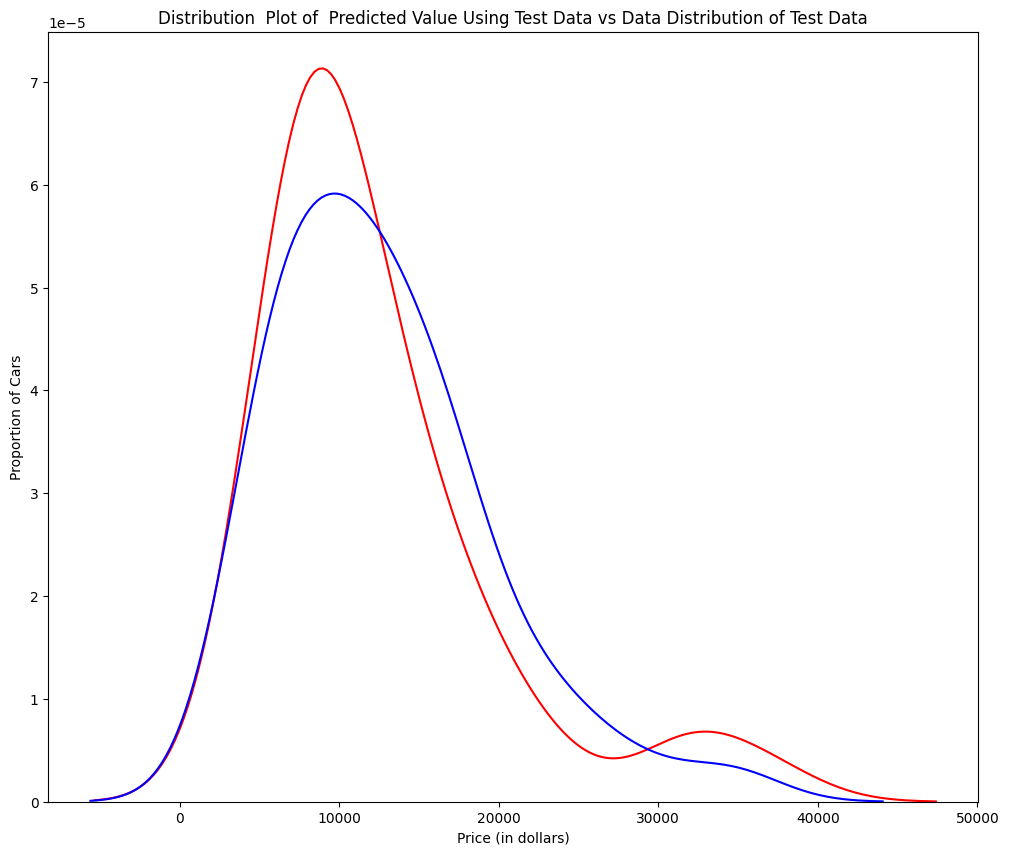

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#Model evaluation
yhat_train = lre.predict(x_train[['horsepower']])
yhat_train[0:5]
yhat_test = lm.predict(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']])
yhat_test[0:5]
Title = 'Distribution  Plot of  Predicted Value Using Training Data vs Training Data Distribution'
DistributionPlot(y_train, yhat_train, "Actual Values (Train)", "Predicted Values (Train)", Title)

Title='Distribution  Plot of  Predicted Value Using Test Data vs Data Distribution of Test Data'
DistributionPlot(y_test,yhat_test,"Actual Values (Test)","Predicted Values (Test)",Title)

Predicted values: [11600.6592143   7487.77266898  9627.3278035   8470.03573061]
True values: [ 9549.  6229. 10245.  7295.]


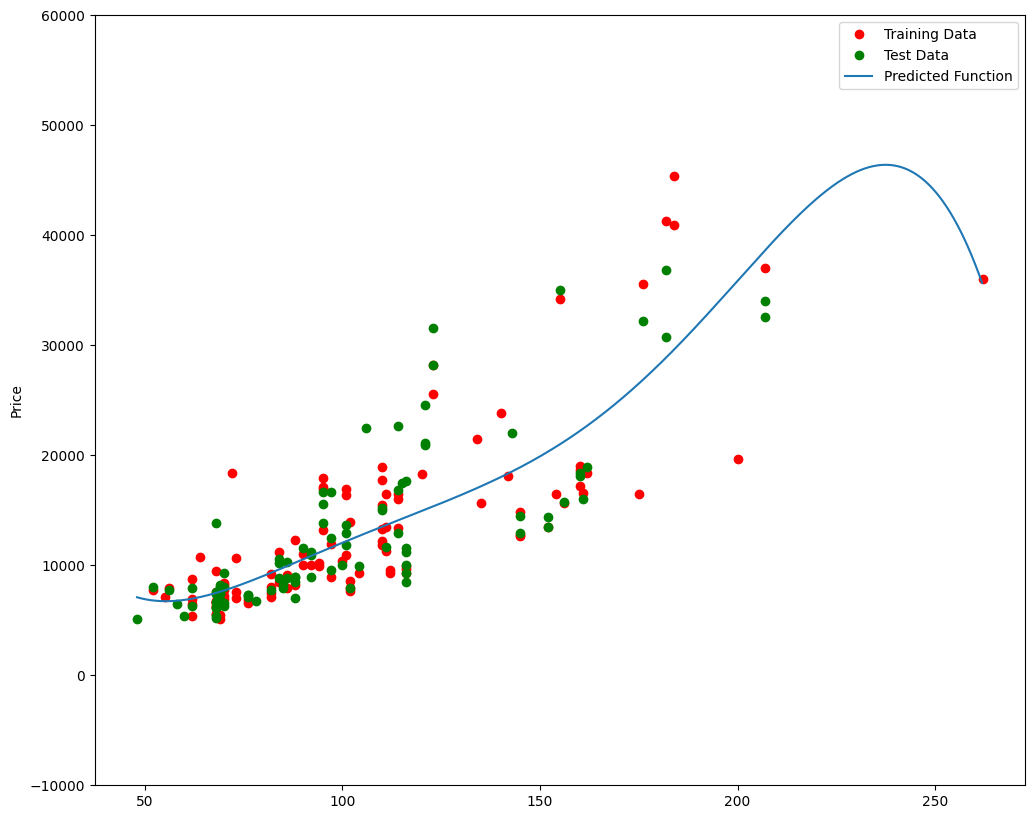

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
x_train,x_test,y_train,y_test=train_test_split(x_data,y_data,test_size=0.45,random_state=1)
pr=PolynomialFeatures(degree=5)
x_train_pr=pr.fit_transform(x_train[['horsepower']])
x_test_pr=pr.fit_transform(x_test[['horsepower']])

poly=LinearRegression()
poly.fit(x_train_pr,y_train)

yhat=poly.predict(x_test_pr)
print("Predicted values:", yhat[0:4])
print("True values:", y_test[0:4].values)

PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly,pr)

In [ ]:
print(poly.score(x_train_pr,y_train))
print(poly.score(x_test_pr,y_test))

0.6751555461310839
0.6681381472716568


__Since the R-squared values for the training and test data are quite close, it suggests that your polynomial model is generalizing reasonably well to new, unseen data, without significant overfitting or underfitting. A higher R-squared value generally indicates a better fit of the model to the data.__

Text(0.5, 1.0, 'R^2 Using Test Data')

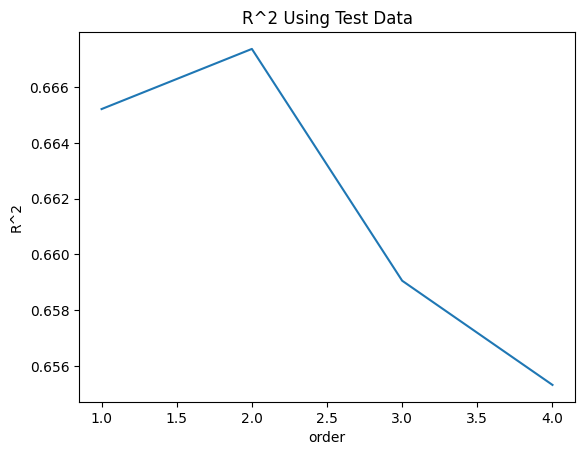

In [ ]:
Rsqu_test = []

order = [1, 2, 3, 4]
for n in order:
    pr = PolynomialFeatures(degree=n)

    x_train_pr = pr.fit_transform(x_train[['horsepower']])

    x_test_pr = pr.fit_transform(x_test[['horsepower']])

    lm.fit(x_train_pr, y_train)

    Rsqu_test.append(lm.score(x_test_pr, y_test))

plt.plot(order, Rsqu_test)
plt.xlabel('order')
plt.ylabel('R^2')
plt.title('R^2 Using Test Data')




#Interpretation:

The graph shows that the R-squared value for the test data peaks at a polynomial order of 2. After this point, increasing the polynomial order (to 3 and 4) actually leads to a slight decrease in the R-squared on the test set. This indicates that while increasing complexity initially helps, going too complex (like order 3 or 4 in this case) might cause the model to start capturing noise in the training data that doesn't generalize well to new, unseen test data. In simpler terms, it could be a sign of starting to overfit the training data, leading to poorer performance on the test data.

In [ ]:
from ipywidgets import interact

def f(order, test_data):
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=test_data, random_state=0)
    pr = PolynomialFeatures(degree=order)
    x_train_pr = pr.fit_transform(x_train[['horsepower']])
    x_test_pr = pr.fit_transform(x_test[['horsepower']])
    poly = LinearRegression()
    poly.fit(x_train_pr,y_train)

    # Calculate and print R-squared for training and test data
    r2_train = poly.score(x_train_pr, y_train)
    r2_test = poly.score(x_test_pr, y_test)
    print(f"R-squared (Training Data, Order {order}): {r2_train:.4f}")
    print(f"R-squared (Test Data, Order {order}): {r2_test:.4f}")

    PollyPlot(x_train['horsepower'], x_test['horsepower'], y_train, y_test, poly,pr)


interact(f, order=(0, 6, 1), test_data=(0.05, 0.95, 0.05))

interactive(children=(IntSlider(value=3, description='order', max=6), FloatSlider(value=0.45, description='tes…

<function __main__.f(order, test_data)>

predicted: [ 9066.34380109  6072.75321106 11158.11851382  4387.20214914]
test set : [ 9549.  6229. 10245.  7295.]


100%|██████████| 1000/1000 [00:10<00:00, 91.34it/s, Test Score=0.813, Train Score=0.876]


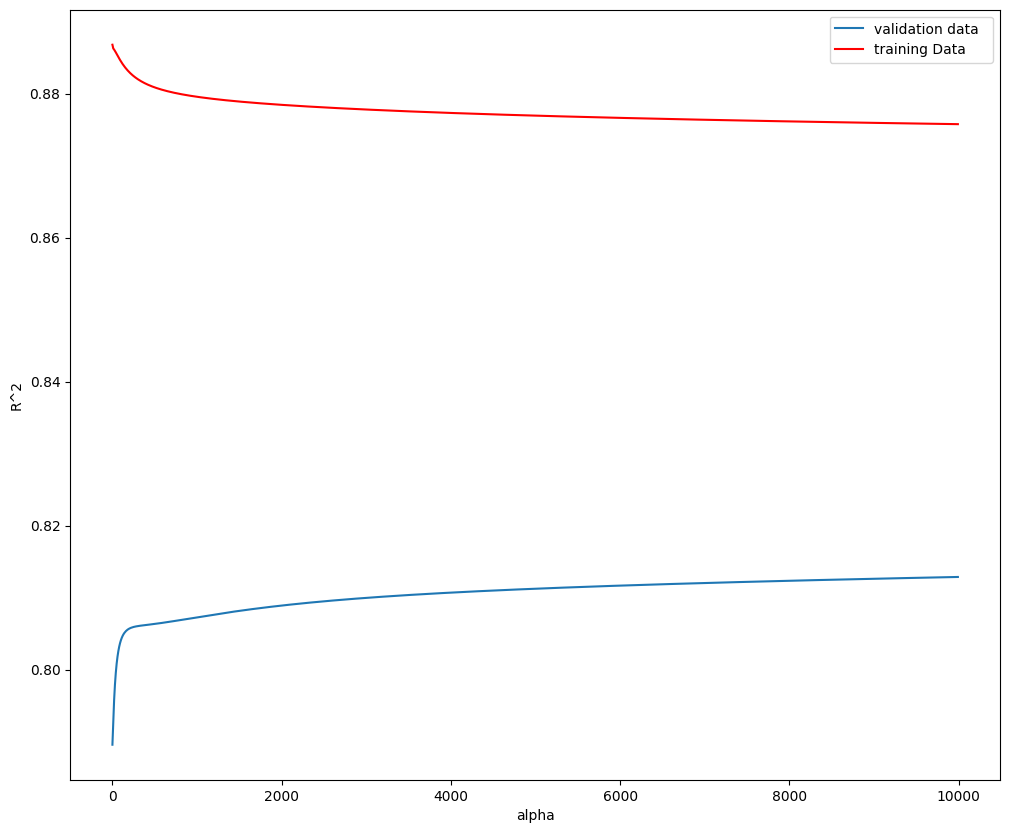

In [ ]:
#-------------------------------------------------------------------------------
#                  RIDGE REGRESSION
#_______________________________________________________________________________

pr=PolynomialFeatures(degree=2)
x_train_pr=pr.fit_transform(x_train[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])
x_test_pr=pr.fit_transform(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg','normalized-losses','symboling']])


from sklearn.linear_model import Ridge
RM=Ridge(alpha=1)
RM.fit(x_train_pr,y_train)
yhatRM=RM.predict(x_test_pr)

print('predicted:', yhatRM[0:4])
print('test set :', y_test[0:4].values)

from tqdm import tqdm

Rsqu_test = []
Rsqu_train = []
dummy1 = []
Alpha = 10 * np.array(range(0,1000))
pbar = tqdm(Alpha)

for alpha in pbar:
    RigeModel = Ridge(alpha=alpha)
    RigeModel.fit(x_train_pr, y_train)
    test_score, train_score = RigeModel.score(x_test_pr, y_test), RigeModel.score(x_train_pr, y_train)

    pbar.set_postfix({"Test Score": test_score, "Train Score": train_score})

    Rsqu_test.append(test_score)
    Rsqu_train.append(train_score)


width = 12
height = 10
plt.figure(figsize=(width, height))

plt.plot(Alpha,Rsqu_test, label='validation data  ')
plt.plot(Alpha,Rsqu_train, 'r', label='training Data ')
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.legend()

__Red Line (training Data)__: This shows the R-squared score on the training data. As alpha increases (more regularization), the training R-squared generally decreases because the model is becoming simpler and might not fit the training data as perfectly.

__Blue Line (validation data)__: This shows the R-squared score on the validation (test) data. Initially, as alpha increases from zero, the validation R-squared tends to increase. This suggests that a small amount of regularization helps the model generalize better to unseen data by preventing overfitting. However, if alpha becomes too large, the model becomes too simple (underfits), and its performance on the validation data will start to decrease.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

# Assuming RM (Ridge model) is already defined and available in the notebook's kernel state
# from a previous execution, otherwise it would also cause a NameError.
# Let's re-define RM here for clarity if it's not universally available.
# RM = Ridge(alpha=1) # If RM is not guaranteed to be defined.

parameters= [{'alpha': [0.001,0.1,1, 10, 100, 1000, 10000, 100000, 100000]}]
Grid1=GridSearchCV(RM,parameters,cv=4)
Grid1.fit(x_data[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_data)

GridSearchCV(cv=4, estimator=Ridge(alpha=1),
             param_grid=[{'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000, 100000,
                                    100000]}])

In [ ]:
BestRR=Grid1.best_estimator_
print(BestRR.score(x_test[['horsepower', 'curb-weight', 'engine-size', 'highway-mpg']], y_test))

print( Grid1.best_params_['alpha'])

0.7765060462921911
10000
